**1. Dinámica del sistema**
**Gráfico temporal (X vs tiempo):**
Muestra la evolución de la variable 
X(t) para dos condiciones iniciales distintas.

**Significado:**
Permite observar cómo X(t) converge a diferentes estados estables dependiendo de las condiciones iniciales, revelando la presencia de múltiples equilibrios (bistabilidad).

Si ambas curvas convergen al mismo valor: un único equilibrio estable.

Si divergen: coexistencia de dos equilibrios estables (dependencia crítica de las condiciones iniciales).


**Diagrama de fase (X vs Y):**
Combina trayectorias de (X,Y) con un campo vectorial.

**Significado:**

Trayectorias: Muestran el camino del sistema desde las condiciones iniciales hasta los equilibrios.

Campo vectorial: Indica la dirección y magnitud del cambio (
dX/dt, dY/dt) en cada punto del espacio de fase.

Puntos de equilibrio: Donde las flechas convergen (nodos estables) o divergen (inestables).

**2. Cuencas de atracción**

**Espacio fase con múltiples trayectorias:**
Trayectorias desde condiciones iniciales aleatorias en los bordes del espacio 
[0,1]×[0,1][0,1].

**Significado:**

Cuencas de atracción: Regiones del espacio fase donde las trayectorias convergen al mismo equilibrio.

Colores/líneas: Cada trayectoria representa una condición inicial. Si se agrupan hacia un punto, ese es su equilibrio asociado.

Fronteras entre cuencas: Líneas que separan regiones que conducen a diferentes equilibrios.

Implicación: Muestra cómo el sistema "elige" su estado final en función de las condiciones iniciales, crucial para entender su sensibilidad a perturbaciones.


**3. Señales de alerta temprana**

Superposición de X(t) para distintos valores de v:
Curvas de X(t) v creciente (de 0.2 a vmax).

**Significado:**

Indicadores de bifurcación:

Aumento de la varianza: Oscilaciones más marcadas cerca de un punto de bifurcación.

Retraso en la estabilización: El sistema tarda más en alcanzar el equilibrio al aproximarse a una bifurcación.

Cambios abruptos: Transiciones repentinas entre estados al superar un valor crítico de v.

Aplicación: Permite predecir cambios críticos en el sistema (ej.: colapso de poblaciones, transiciones de fase).



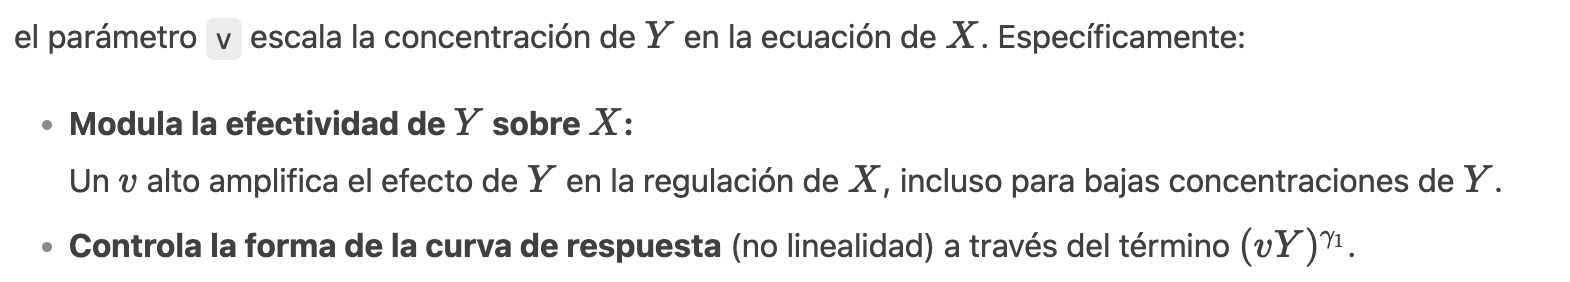

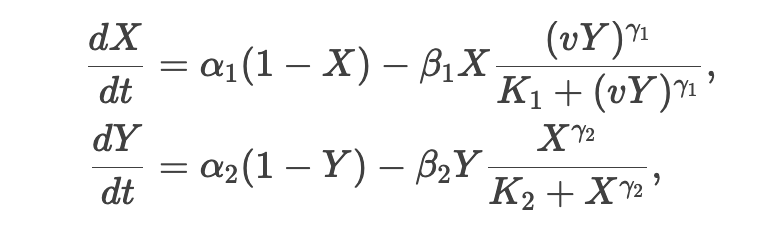

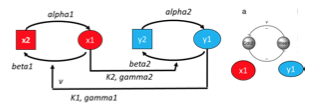

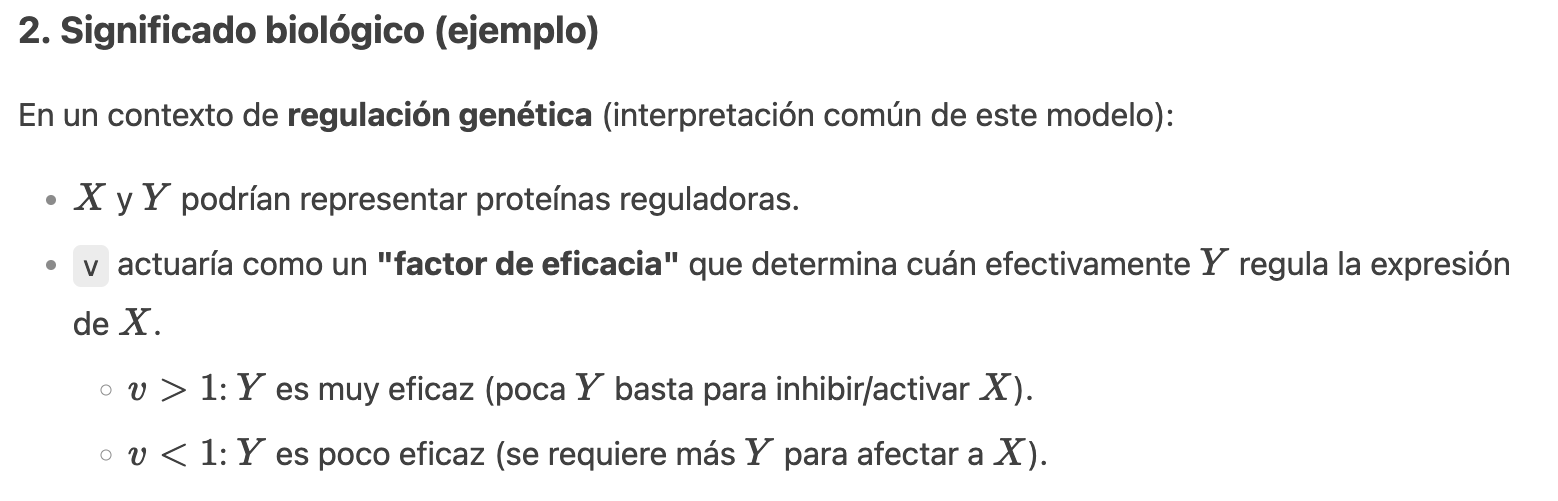

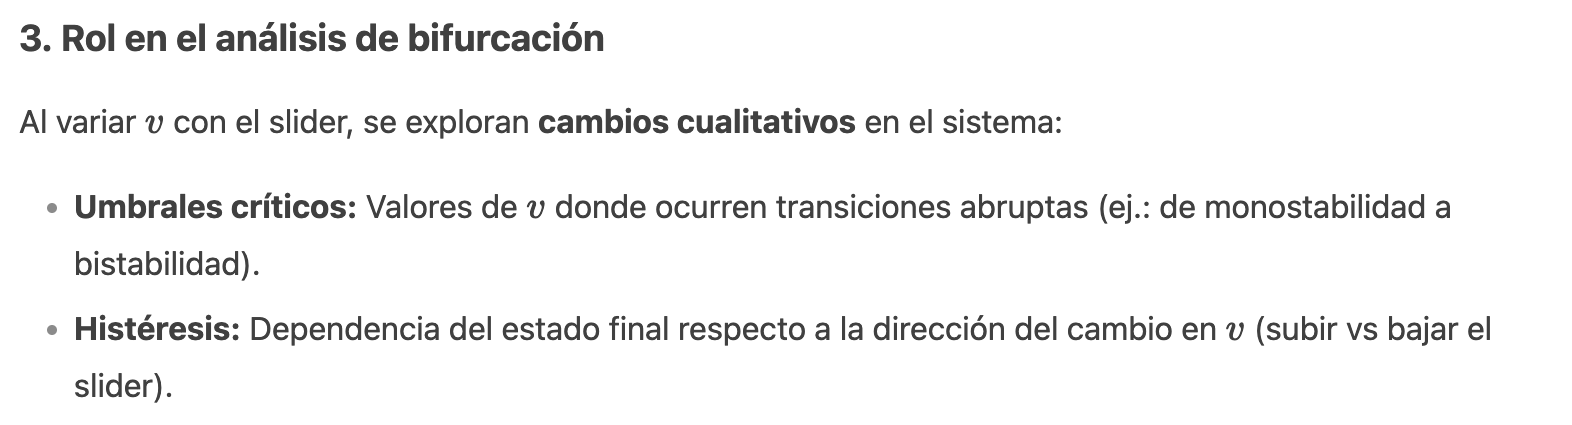

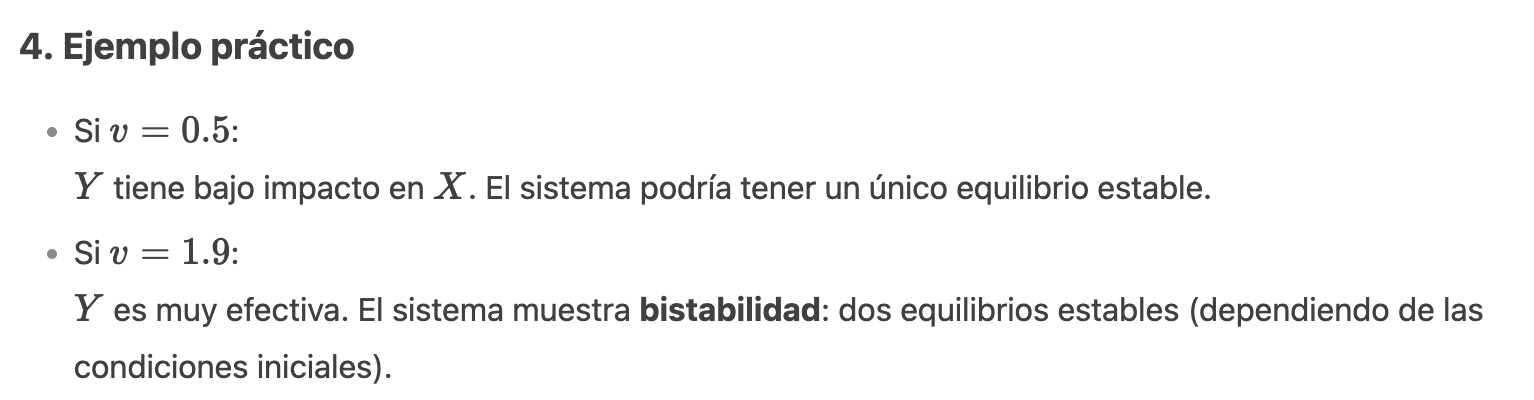



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider, FloatRangeSlider
plt.style.use('ggplot')

# Definición del modelo
def angeli_model(t, state, alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v):
    x, y = state
    dxdt = alpha1*(1 - x) - beta1*x*(v*y)**gamma1/(K1 + (v*y)**gamma1)
    dydt = alpha2*(1 - y) - beta2*y*x**gamma2/(K2 + x**gamma2)
    return [dxdt, dydt]

# Parámetros fijos
fixed_params = {
    'alpha1': 1,
    'alpha2': 1,
    'beta1': 200,
    'beta2': 10,
    'gamma1': 4,
    'gamma2': 4,
    'K1': 30,
    'K2': 1
}

# Función común para resolver el ODE
def solve_system(v, initial_conditions, t_span=(0, 10), t_eval=np.linspace(0, 10, 1000)):
    sols = []
    for ic in initial_conditions:
        sol = solve_ivp(angeli_model, t_span, ic, args=tuple(fixed_params.values()) + (v,),
                        t_eval=t_eval, method='Radau')
        sols.append(sol)
    return sols

# ---------------------------------------------------------------
# Pregunta 1: Dinámica del sistema
# ---------------------------------------------------------------
def plot_dynamics(v=1.0):
    initial_conditions = [(0, 0), (0, 0.9)]
    sols = solve_system(v, initial_conditions)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico de series temporales
    for i, sol in enumerate(sols):
        ax1.plot(sol.t, sol.y[0], label=f'Condición inicial {i+1}')
    ax1.set_title(f'Dinámica temporal (v = {v})')
    ax1.set_xlabel('Tiempo')
    ax1.set_ylabel('X(t)')
    ax1.set_ylim(0, 1)
    ax1.legend()
    
    # Diagrama de fase
    x = np.linspace(0, 1, 20)
    y = np.linspace(0, 1, 20)
    X, Y = np.meshgrid(x, y)
    
    DX, DY = np.zeros_like(X), np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dxdt, dydt = angeli_model(None, [X[i,j], Y[i,j]], *fixed_params.values(), v)
            DX[i,j] = dxdt
            DY[i,j] = dydt
    
    ax2.streamplot(X, Y, DX, DY, density=1.5, color='gray', linewidth=1)
    for sol in sols:
        ax2.plot(sol.y[0], sol.y[1], lw=2)
    ax2.set_title('Espacio fase')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

interact(plot_dynamics,
         v=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='v'));

# ---------------------------------------------------------------
# Pregunta 2: Cuencas de atracción
# ---------------------------------------------------------------
def plot_basins(v=1.0):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Campo vectorial
    x = np.linspace(0, 1, 20)
    y = np.linspace(0, 1, 20)
    X, Y = np.meshgrid(x, y)
    
    DX, DY = np.zeros_like(X), np.zeros_like(Y)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            dxdt, dydt = angeli_model(None, [X[i,j], Y[i,j]], *fixed_params.values(), v)
            DX[i,j] = dxdt
            DY[i,j] = dydt
    
    ax.streamplot(X, Y, DX, DY, density=1.5, color='lightgray')
    
    # Trayectorias aleatorias
    np.random.seed(42)
    for _ in range(20):
        if np.random.rand() < 0.5:
            ic = [np.random.rand(), np.random.choice([0, 1])]
        else:
            ic = [np.random.choice([0, 1]), np.random.rand()]
        
        sol = solve_ivp(angeli_model, (0, 10), ic, args=tuple(fixed_params.values()) + (v,),
                        t_eval=np.linspace(0, 10, 1000), method='Radau')
        ax.plot(sol.y[0], sol.y[1], lw=1)
    
    ax.set_title(f'Cuencas de atracción (v = {v})')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.show()

interact(plot_basins,
         v=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='v'));

# ---------------------------------------------------------------
# Pregunta 3: Señales de alerta temprana
# ---------------------------------------------------------------
def plot_early_warning(v_max=1.0):
    plt.figure(figsize=(10, 6))
    
    for i, v in enumerate(np.arange(0.2, v_max+0.01, 0.1)):
        sols = solve_system(v, [(0, 0.9)])
        plt.plot(sols[0].t, sols[0].y[0], 
                 lw=0.5 + i*0.2, 
                 alpha=0.7, 
                 label=f'v = {v:.1f}' if i%2 == 0 else None)
    
    plt.title('Señales de alerta temprana')
    plt.xlabel('Tiempo')
    plt.ylabel('X(t)')
    plt.legend()
    plt.show()

interact(plot_early_warning,
         v_max=FloatSlider(value=1.0, min=0.3, max=2.0, step=0.1, description='v máximo'));

# ---------------------------------------------------------------
# Pregunta 4: Diagrama de bifurcación
# ---------------------------------------------------------------
# Parámetros fijos
fixed_params = {
    'alpha1': 1,
    'alpha2': 1,
    'beta1': 200,
    'beta2': 10,
    'gamma1': 4,
    'gamma2': 4,
    'K1': 30,
    'K2': 1
}



interactive(children=(FloatSlider(value=1.0, description='v', max=2.0, min=0.1), Output()), _dom_classes=('wid…

interactive(children=(FloatSlider(value=1.0, description='v', max=2.0, min=0.1), Output()), _dom_classes=('wid…

interactive(children=(FloatSlider(value=1.0, description='v máximo', max=2.0, min=0.3), Output()), _dom_classe…